# Music Certification Deep Learning Model

This notebook builds a CNN-based deep learning model to predict music certification (Certified Units) based on certification metrics (Gold, Platinum, Multi-Platinum, Diamond).

## Overview
- **Data Source**: riaakaggle.csv
- **Features**: Gold, Platinum, Multi-Platinum, Diamond certifications
- **Target**: Certified Units
- **Model**: 1D Convolutional Neural Network (Conv1D)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

## Step 1: Import Required Libraries

Import all necessary libraries for data processing, model building, and visualization.

In [3]:
df = pd.read_csv("riaakaggle.csv")

## Step 2: Load Data

Load the dataset from CSV file.

In [4]:
df

,Artist ID,Artist,Certified Units,Gold,Platinum,Multi-Platinum,Diamond
0,4dd6f6958de61830ebf316d75cdbf99c,THE BEATLES,183.0,48,42,26,6
1,9a985af435ee5174d2f3883aecf04be5,GARTH BROOKS,157.0,31,31,17,9
2,72de4063a117bfdc4ea56cd7407d0375,ELVIS PRESLEY,139.0,101,57,25,1
3,35f1d0d83ce31283098108caa454990e,EAGLES,120.0,13,13,11,3
4,700c19b4be6fea62a79ef39655f0a14d,LED ZEPPELIN,111.5,19,18,14,5
...,...,...,...,...,...,...,...
2651,32fd2546eda192d78bfcc515ca2f69e7,YOUNGBLOODZ,0.5,1,0,0,0
2652,e777ad787fcd58d6895c94eb1dd4e214,YUKMOUTH,0.5,1,0,0,0
2653,7ef45efaf7a7cfa93a220288f7975038,YUNG JOC,0.5,1,0,0,0
2654,239f32e37fc893d0be9a1047039734ff,ZACH WILLIAMS,0.5,1,0,0,0


In [18]:
X = df[["Gold", "Platinum", "Multi-Platinum", "Diamond"]].values
y = df["Certified Units"].values

## Step 3: Prepare Features and Target

Extract the feature columns (certification types) and target variable (Certified Units).

In [19]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Step 4: Normalize Features

Scale features using StandardScaler to normalize the data for better model performance.

In [20]:
X = X.reshape(X.shape[0], X.shape[1], 1)

## Step 5: Reshape Data for Conv1D

Reshape data to 3D format required by Conv1D layer: (samples, timesteps, features).

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 6: Train-Test Split

Split data into training (80%) and testing (20%) sets.

In [28]:
model = Sequential([
    Conv1D(32, kernel_size=2, activation="relu", input_shape=(4, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=1, activation="relu"),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1)
])

## Step 7: Build CNN Model

Create a Sequential CNN model with:
- Conv1D layer (32 filters, kernel_size=2)
- MaxPooling layer (pool_size=2)
- Conv1D layer (64 filters, kernel_size=1) - reduced kernel size to handle pooled dimension
- Flatten layer
- Dense layer (64 units, ReLU activation)
- Dropout (30%) for regularization
- Output Dense layer (1 unit for regression)

In [29]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 8: Compile Model

Configure the model with:
- Optimizer: Adam
- Loss: Mean Squared Error (MSE) for regression
- Metrics: Mean Absolute Error (MAE)

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 127.3504 - mae: 4.1712 - val_loss: 111.8708 - val_mae: 3.2034
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51.2512 - mae: 2.5572 - val_loss: 25.3037 - val_mae: 1.4690
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.7891 - mae: 1.4950 - val_loss: 18.9271 - val_mae: 1.4159
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.9682 - mae: 1.5592 - val_loss: 19.0538 - val_mae: 1.3228
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.5769 - mae: 1.4862 - val_loss: 21.8469 - val_mae: 1.3093
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.0358 - mae: 1.4677 - val_loss: 19.4791 - val_mae: 1.1751
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.7663 - mae: 1.3393 - val_loss: 15.0666 - val_mae: 1.2074
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.3794 - mae: 1.3733 - val_loss: 18.3095 - val_mae: 1.1370
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

## Step 9: Train Model

Train the model for 50 epochs with batch size of 32 and 20% validation split.

In [31]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1220 - mae: 0.8768 
Test MAE: 0.8768287897109985


## Step 10: Evaluate Model

Evaluate the trained model on the test set.

In [33]:
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(X_test).flatten()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


## Step 11: Generate Predictions

Make predictions on the test set for visualization and analysis.

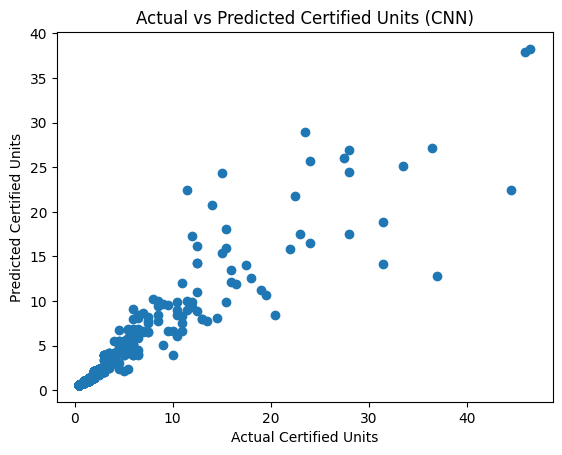

In [34]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Certified Units")
plt.ylabel("Predicted Certified Units")
plt.title("Actual vs Predicted Certified Units (CNN)")
plt.show()

## Step 12: Visualize Predictions - Scatter Plot

Create a scatter plot comparing actual vs predicted values.

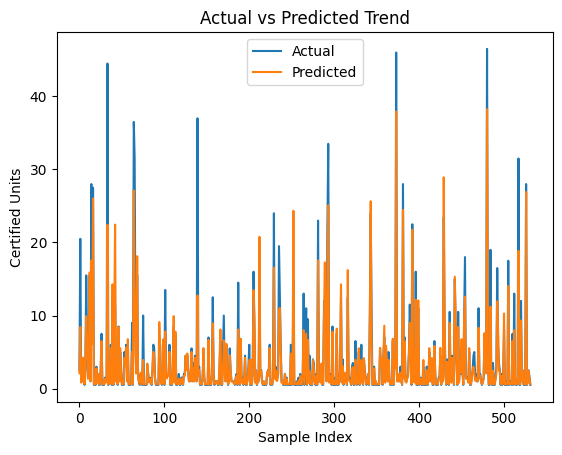

In [35]:
plt.figure()
plt.plot(y_test)
plt.plot(y_pred)
plt.xlabel("Sample Index")
plt.ylabel("Certified Units")
plt.title("Actual vs Predicted Trend")
plt.legend(["Actual", "Predicted"])
plt.show()

## Step 13: Visualize Predictions - Trend Line

Create a line plot showing the trend of actual vs predicted values.

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8508689100690594


## Step 14: Calculate R² Score

Compute the R² score to measure model performance (coefficient of determination).